<a href="https://colab.research.google.com/github/nfcr7/TP1/blob/main/tp-with-my-own-code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

im going to import most of the libraries i need like numpy pandas or matpolotlib for data structure and calculating to fill the blank or null and load the dataset AmesHousing with a pandas command

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv('AmesHousing.csv')


before checking the missing values we can check on the dataset dimension so we get an idea on the number of row and columns

In [5]:
print(df.shape)

(2930, 82)


In [6]:
print(df.isna().sum())

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64


im going to replace the missing values with the mean of the column

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [8]:
print(df.isna().sum())

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64


and for catgorical we fill the missing value with the mode frequent value or the mode

In [9]:
category = df.select_dtypes(include="object").columns

for col in category:
    df[col] = df[col].fillna(df[col].mode()[0])

one hot encoding to convert the categorical variables into numerical

In [10]:
df = pd.get_dummies(df)

we define the target variable to y variable and the feautres that gonna help the mode to predict the price to the X variable we drop the feature axis = 1 because it the sale price

In [11]:
target = "SalePrice"

X = df.drop(target, axis=1)
y = df[target]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from tensorflow.keras import layers
model = keras.Sequential([

    layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),

    layers.Dense(64, activation='relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(1)

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=70,
    validation_split=0.2
)

Epoch 1/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 37975961600.0000 - mae: 179410.8281 - val_loss: 38141456384.0000 - val_mae: 179925.6250
Epoch 2/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37620068352.0000 - mae: 179340.4375 - val_loss: 36551290880.0000 - val_mae: 176407.9844
Epoch 3/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34299045888.0000 - mae: 170200.0938 - val_loss: 27033976832.0000 - val_mae: 153179.8281
Epoch 4/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22598201344.0000 - mae: 139422.1719 - val_loss: 10609842176.0000 - val_mae: 89919.8047
Epoch 5/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7824994304.0000 - mae: 73995.5625 - val_loss: 5551860736.0000 - val_mae: 60077.1953
Epoch 6/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4463755264.0000 - mae: 52616.8594 - val_loss: 3659723008.0000 - val_mae: 45685.7227
Epoch 7/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2568943360.0000 - mae: 38487.7891 - val_loss: 2832483840.0000 - val_mae: 38

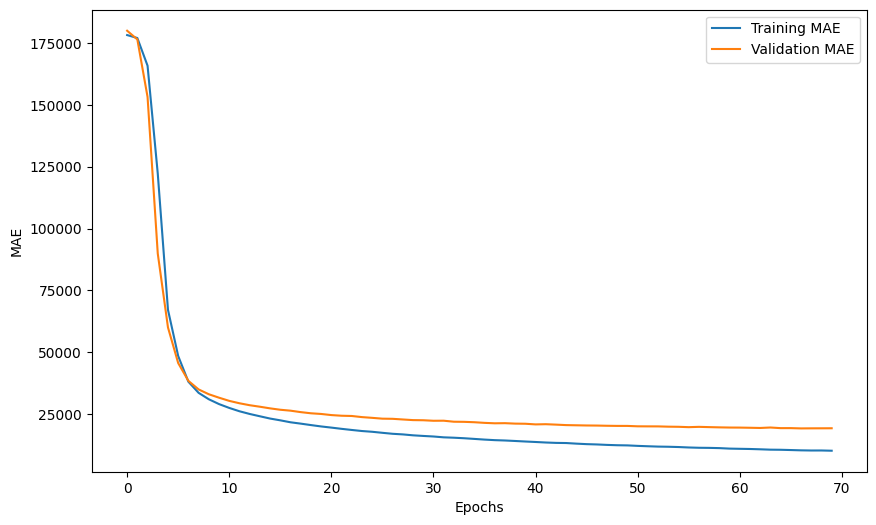

In [17]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10,6))

plt.plot(history_df["mae"], label="Training MAE")
plt.plot(history_df["val_mae"], label="Validation MAE")

plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()

plt.show()

In [18]:
loss, mae = model.evaluate(X_test, y_test)

print("Test MAE:", mae)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1212568832.0000 - mae: 18303.4941
Test MAE: 17970.705078125


In [19]:
prediction = model.predict(X_test[:1])

print("Predicted price:", prediction[0][0])
print("Actual price:", y_test.iloc[0])
print("Accuracy", (prediction[0][0] - y_test.iloc[0]) / y_test.iloc[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Predicted price: 145876.66
Actual price: 161000
Accuracy -0.09393381211180124
